# SVD Data Compression Using the Wine Dataset

### Project II — Data Science and Engineering

**Topic:** Data Compression Using Singular Value Decomposition (SVD)

**Dataset:** Wine Dataset

This project applies Singular Value Decomposition (SVD) to the Wine dataset to investigate how a numerical dataset can be represented using a lower-rank approximation while preserving important information.


### 1. Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

### 2. Load the Wine dataset

In [2]:
wine = load_wine()

X = wine.data
y = wine.target

print("Dataset shape:", X.shape)
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

Dataset shape: (178, 13)
Number of samples: 178
Number of features: 13


### 3. Display the dataset

In [3]:
df = pd.DataFrame(X, columns=wine.feature_names)

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


### 4. Check missing values

In [4]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64


### 5. Standardize the data

In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (178, 13)


The Wine features have very different scales. For example, proline has much larger numerical values than some other features.

If we directly apply SVD to the raw data, features with large numerical scales can dominate the decomposition.

### 6. Apply SVD

In [6]:
U, S, VT = np.linalg.svd(X_scaled, full_matrices=False)

print("U shape:", U.shape)
print("S shape:", S.shape)
print("VT shape:", VT.shape)

U shape: (178, 13)
S shape: (13,)
VT shape: (13, 13)


In [7]:
Sigma = np.diag(S)

print("U =")
print(U)

print("\nSigma =")
print(Sigma)

print("\nVT =")
print(VT)

U =
[[-1.14599782e-01 -6.84681444e-02 -1.03304651e-02 ...  7.12291375e-02
  -9.86704519e-02  1.54414265e-02]
 [-7.63410374e-02  1.58139129e-02 -1.26308483e-01 ...  2.25026142e-02
  -7.08336829e-02 -8.47734696e-04]
 [-8.69579563e-02 -4.89108718e-02  6.12587940e-02 ...  4.52194750e-02
  -1.06472487e-04 -5.06251253e-03]
 ...
 [ 9.25242310e-02 -1.30958458e-01 -5.86486260e-02 ... -8.08399557e-02
  -1.27489412e-01 -1.68026182e-02]
 [ 8.24757884e-02 -1.08970652e-01 -3.43247294e-02 ... -4.72936035e-02
  -6.20000218e-02  5.09730544e-03]
 [ 1.10868439e-01 -1.31338893e-01  6.31969357e-02 ...  3.62743329e-02
   3.44442214e-02  7.55220534e-02]]

Sigma =
[[28.94203422  0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.        ]
 [ 0.         21.08225141  0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.        ]
 [ 0.          0.         16.04371561  0.          0.    

### 7. Singular Values and Cumulative Sum

In [8]:
print("Singular values:")
print(S)

Singular values:
[28.94203422 21.08225141 16.04371561 12.78973645 12.32374195 10.68713954
  9.90368818  7.8760733   7.17081793  6.6828618   6.33958815  5.48097635
  4.28967045]


In [9]:
# Calculate cumulative sum of singular values
cumulative_sum = np.cumsum(S)

results = pd.DataFrame({
    "r": np.arange(1, len(S) + 1),
    "Singular Value": S,
    "Cumulative Sum": cumulative_sum
})

results

,r,Singular Value,Cumulative Sum
0,1,28.942034,28.942034
1,2,21.082251,50.024286
2,3,16.043716,66.068001
3,4,12.789736,78.857738
4,5,12.323742,91.181480
5,6,10.687140,101.868619
6,7,9.903688,111.772307
7,8,7.876073,119.648381
8,9,7.170818,126.819199
9,10,6.682862,133.502060


### 8. Singular Values vs. r

This graph shows the singular values obtained from the SVD decomposition.

The x-axis represents the number of components (r), while the y-axis represents the corresponding singular value.

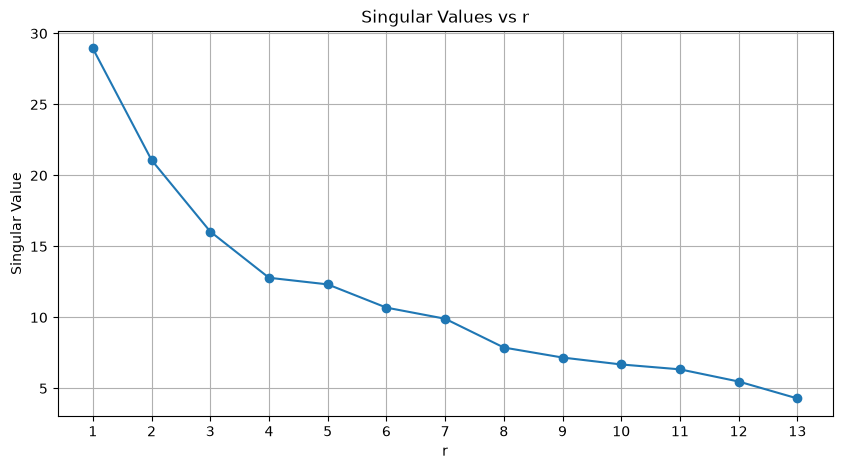

In [10]:
# Singular Values vs r

r_values = np.arange(1, len(S) + 1)

plt.figure(figsize=(10, 5))

plt.plot(
    r_values,
    S,
    marker='o'
)

plt.xlabel("r")
plt.ylabel("Singular Value")
plt.title("Singular Values vs r")
plt.xticks(r_values)
plt.grid(True)

plt.show()

### 9. Cumulative Sum of Singular Values vs r

This graph shows the percentage of total information retained when the first r singular values are used.

As r increases, more information from the original dataset is retained.

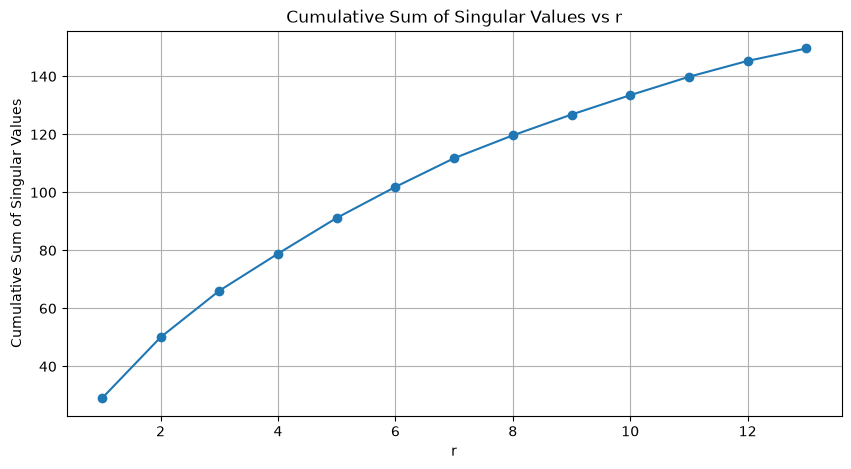

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(S) + 1),
    cumulative_sum,
    marker='o'
)

plt.xlabel("r")
plt.ylabel("Cumulative Sum of Singular Values")
plt.title("Cumulative Sum of Singular Values vs r")
plt.grid(True)

plt.show()

### 10. Select r 

In [12]:
# Select r
r = 8

print("Selected r =", r)
print("Original number of components =", len(S))
print("Compressed number of components =", r)

Selected r = 8
Original number of components = 13
Compressed number of components = 8


### 11. Perform the SVD compression

In [13]:
# Keep only the first r components
U_r = U[:, :r]
S_r = S[:r]
VT_r = VT[:r, :]

# Reconstruct the compressed dataset
X_compressed = U_r @ np.diag(S_r) @ VT_r

print("Original data shape:", X_scaled.shape)
print("Compressed data shape:", X_compressed.shape)

Original data shape: (178, 13)
Compressed data shape: (178, 13)


### 12. Show the selected components

In [14]:
print("Selected singular values:")
print(S_r)

Selected singular values:
[28.94203422 21.08225141 16.04371561 12.78973645 12.32374195 10.68713954
  9.90368818  7.8760733 ]


In [15]:
# Reconstruct the dataset using r = 8
r = 8

X_compressed = U[:, :r] @ np.diag(S[:r]) @ VT[:r, :]

print("Original dataset shape:", X_scaled.shape)
print("Compressed dataset shape:", X_compressed.shape)
print("Number of components before compression:", len(S))
print("Number of components after compression:", r)

Original dataset shape: (178, 13)
Compressed dataset shape: (178, 13)
Number of components before compression: 13
Number of components after compression: 8


### 13. Result

In [16]:
# Display first 5 rows of original data
original_df = pd.DataFrame(
    X_scaled[:5],
    columns=wine.feature_names
)

print("Original data:")
display(original_df)

# Display first 5 rows of compressed/reconstructed data
compressed_df = pd.DataFrame(
    X_compressed[:5],
    columns=wine.feature_names
)

print("Compressed data:")
display(compressed_df)


Original data:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


Compressed data:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.019310,-0.227960,0.249406,-1.099416,1.672826,1.223406,1.236312,-0.967583,1.158790,0.199339,0.672559,0.910793,1.504242
1,0.440681,-0.509734,-0.970058,-2.347685,0.076935,0.871196,0.784959,-0.794942,-0.627083,-0.459518,0.408799,0.846073,0.869227
2,0.707027,-0.011111,0.610131,0.096820,0.419499,1.279687,1.267009,-0.261562,1.808968,0.377232,0.466595,0.907211,0.852916
3,1.726851,-0.287909,0.825199,-1.176119,0.882294,2.076935,1.819620,-1.080156,1.124991,1.370347,-0.240841,1.103756,1.902516
4,-0.029270,0.296731,1.654594,0.637864,1.254085,0.747837,0.677605,0.259500,0.325451,-0.213729,0.316860,0.587978,0.430578
